### **Imports**

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

### **Read The CSV File & Convert To Dataframe**

In [3]:
df = pd.read_csv('italy-covid-daywise.csv')

In [4]:
df.head()

,date,new_cases,new_deaths,new_tests
0,2019-12-31,0.0,0.0,NaN
1,2020-01-01,0.0,0.0,NaN
2,2020-01-02,0.0,0.0,NaN
3,2020-01-03,0.0,0.0,NaN
4,2020-01-04,0.0,0.0,NaN


### **Retrieve the number of rows and columns in the dataframe**


In [5]:
df.shape

(248, 4)

### **View statistical information for numerical columns**

In [7]:
df.describe()

,new_cases,new_deaths,new_tests
count,248.000000,248.000000,135.000000
mean,1094.818548,143.133065,31699.674074
std,1554.508002,227.105538,11622.209757
min,-148.000000,-31.000000,7841.000000
25%,123.000000,3.000000,25259.000000
50%,342.000000,17.000000,29545.000000
75%,1371.750000,175.250000,37711.000000
max,6557.000000,971.000000,95273.000000


#### **View some basic information about the data frame like data types, and number of non-nulls**

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        248 non-null    object 
 1   new_cases   248 non-null    float64
 2   new_deaths  248 non-null    float64
 3   new_tests   135 non-null    float64
dtypes: float64(3), object(1)
memory usage: 7.9+ KB


### **Create a list of columns within the dataframe**

In [15]:
column_names = list(df.columns)
column_names

['date', 'new_cases', 'new_deaths', 'new_tests']

### **Return only the days which had more than 1000 reported cases**

In [16]:
df[df['new_cases'] > 1000]['date']

,date
68,2020-03-08
69,2020-03-09
70,2020-03-10
72,2020-03-12
73,2020-03-13
...,...
241,2020-08-28
242,2020-08-29
243,2020-08-30
244,2020-08-31


### **Create positive_rate column that is equal to (new_cases / new_tests)**

In [17]:
df['positive_rate'] = df['new_cases'] / df['new_tests']

In [21]:
df.tail(10)

,date,new_cases,new_deaths,new_tests,positive_rate
238,2020-08-25,953.0,4.0,45798.0,0.020809
239,2020-08-26,876.0,4.0,58054.0,0.015089
240,2020-08-27,1366.0,13.0,57640.0,0.023699
241,2020-08-28,1409.0,5.0,65135.0,0.021632
242,2020-08-29,1460.0,9.0,64294.0,0.022708
243,2020-08-30,1444.0,1.0,53541.0,0.026970
244,2020-08-31,1365.0,4.0,42583.0,0.032055
245,2020-09-01,996.0,6.0,54395.0,0.018311
246,2020-09-02,975.0,8.0,NaN,NaN
247,2020-09-03,1326.0,6.0,NaN,NaN


### **Let's remove the positive_rate column**

In [22]:
df.drop(labels=['positive_rate'], axis=1, inplace=True)

In [23]:
df.head()

,date,new_cases,new_deaths,new_tests
0,2019-12-31,0.0,0.0,NaN
1,2020-01-01,0.0,0.0,NaN
2,2020-01-02,0.0,0.0,NaN
3,2020-01-03,0.0,0.0,NaN
4,2020-01-04,0.0,0.0,NaN


### **Sort to identify the days with the highest number of cases**

In [25]:
df.sort_values(by=['new_cases'], ascending=False, inplace=True)

In [26]:
df.head()

,date,new_cases,new_deaths,new_tests
82,2020-03-22,6557.0,795.0,NaN
87,2020-03-27,6153.0,660.0,NaN
81,2020-03-21,5986.0,625.0,NaN
89,2020-03-29,5974.0,887.0,NaN
88,2020-03-28,5959.0,971.0,NaN


### **Check the data type of date column, then convert it into a datetime**

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 248 entries, 82 to 172
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        248 non-null    object 
 1   new_cases   248 non-null    float64
 2   new_deaths  248 non-null    float64
 3   new_tests   135 non-null    float64
dtypes: float64(3), object(1)
memory usage: 17.8+ KB


In [32]:
df['date'] = pd.to_datetime(df['date'])

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 248 entries, 82 to 172
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        248 non-null    datetime64[ns]
 1   new_cases   248 non-null    float64       
 2   new_deaths  248 non-null    float64       
 3   new_tests   135 non-null    float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 17.8 KB


In [34]:
df.head()

,date,new_cases,new_deaths,new_tests
82,2020-03-22,6557.0,795.0,NaN
87,2020-03-27,6153.0,660.0,NaN
81,2020-03-21,5986.0,625.0,NaN
89,2020-03-29,5974.0,887.0,NaN
88,2020-03-28,5959.0,971.0,NaN


### **Extract different parts (day, month, weekday, and year) of the date column into separate columns**

In [41]:
df['day'] = df['date'].apply(lambda date : date.day)
df['month'] = df['date'].apply(lambda date : date.month)
df['year'] = df['date'].apply(lambda date : date.year)

# Get the weekday and map the number to string for better readability
df['weekday'] = df['date'].apply(lambda date : date.weekday())
df['weekday'].replace({0	: 'Monday',
                       1	: 'Tuesday',
                       2	: 'Wednesday',
                       3	: 'Thursday',
                       4	: 'Friday',
                       5	: 'Saturday',
                       6	: 'Sunday'}, inplace=True)

<ipython-input-41-f42552716abd>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['weekday'].replace({0	: 'Monday',


In [42]:
df.head()

,date,new_cases,new_deaths,new_tests,day,month,weekday,year
82,2020-03-22,6557.0,795.0,NaN,22,3,Sunday,2020
87,2020-03-27,6153.0,660.0,NaN,27,3,Friday,2020
81,2020-03-21,5986.0,625.0,NaN,21,3,Saturday,2020
89,2020-03-29,5974.0,887.0,NaN,29,3,Sunday,2020
88,2020-03-28,5959.0,971.0,NaN,28,3,Saturday,2020


### **Check the overall metrics for May (i.e, the total numbers of 'new_cases', 'new_deaths', 'new_tests')**

In [49]:
df[df['month'] == 5][['new_cases', 'new_deaths', 'new_tests']].sum()    # Get the total numbers of 'new_cases', 'new_deaths', 'new_tests'

,0
new_cases,29073.0
new_deaths,5658.0
new_tests,1078720.0


In [45]:
df[df['month'] == 5].describe()     # # Get the describtive statistics of 'new_cases', 'new_deaths', 'new_tests' for May

,date,new_cases,new_deaths,new_tests,day,month,year
count,31,31.000000,31.000000,31.000000,31.000000,31.0,31.0
mean,2020-05-16 00:00:00,937.838710,182.516129,34797.419355,16.000000,5.0,2020.0
min,2020-05-01 00:00:00,300.000000,50.000000,13665.000000,1.000000,5.0,2020.0
25%,2020-05-08 12:00:00,617.500000,118.000000,31307.500000,8.500000,5.0,2020.0
50%,2020-05-16 00:00:00,802.000000,165.000000,37049.000000,16.000000,5.0,2020.0
75%,2020-05-23 12:00:00,1274.000000,239.000000,40032.000000,23.500000,5.0,2020.0
max,2020-05-31 00:00:00,1965.000000,474.000000,45428.000000,31.000000,5.0,2020.0
std,NaN,458.224843,91.088188,7403.552952,9.092121,0.0,0.0


### **Which day seems like have more cases ?**

In [47]:
df[df['new_cases'] == df['new_cases'].max()]['date']  # Get the full date of the day

,date
82,2020-03-22


In [46]:
df[df['new_cases'] == df['new_cases'].max()]['day']   # Extract the day part only

,day
82,22


### **Create a new dataframe with month-wise data**

In [50]:
new_df = df.copy()    # Get a copy of the dataframe

In [51]:
new_df.head()

,date,new_cases,new_deaths,new_tests,day,month,weekday,year
82,2020-03-22,6557.0,795.0,NaN,22,3,Sunday,2020
87,2020-03-27,6153.0,660.0,NaN,27,3,Friday,2020
81,2020-03-21,5986.0,625.0,NaN,21,3,Saturday,2020
89,2020-03-29,5974.0,887.0,NaN,29,3,Sunday,2020
88,2020-03-28,5959.0,971.0,NaN,28,3,Saturday,2020


In [58]:
new_df.sort_values(by='date', inplace=True)      # Sort the data first by date (in ascending order)

In [59]:
new_df.head()     # Observe the smallest date we have

,date,new_cases,new_deaths,new_tests,day,month,weekday,year
0,2019-12-31,0.0,0.0,NaN,31,12,Tuesday,2019
1,2020-01-01,0.0,0.0,NaN,1,1,Wednesday,2020
2,2020-01-02,0.0,0.0,NaN,2,1,Thursday,2020
3,2020-01-03,0.0,0.0,NaN,3,1,Friday,2020
4,2020-01-04,0.0,0.0,NaN,4,1,Saturday,2020


In [60]:
new_df.tail()   # Observe the largest date we have

,date,new_cases,new_deaths,new_tests,day,month,weekday,year
243,2020-08-30,1444.0,1.0,53541.0,30,8,Sunday,2020
244,2020-08-31,1365.0,4.0,42583.0,31,8,Monday,2020
245,2020-09-01,996.0,6.0,54395.0,1,9,Tuesday,2020
246,2020-09-02,975.0,8.0,NaN,2,9,Wednesday,2020
247,2020-09-03,1326.0,6.0,NaN,3,9,Thursday,2020


In [65]:
new_df.drop(['date', 'day', 'weekday', 'year'], axis=1, inplace=True)     # Drop Unnecessary columns

In [67]:
new_df = new_df.groupby(by=['month']).sum()   # Get the total number of cases, death, new_tests each month

In [68]:
new_df.head()   # Display the new dataframe

,new_cases,new_deaths,new_tests
month,,,
1,3.0,0.0,0.0
2,885.0,21.0,0.0
3,100851.0,11570.0,0.0
4,101852.0,16091.0,419591.0
5,29073.0,5658.0,1078720.0


### **Plot a line graph showing how the number of daily cases varies over time**

In [52]:
sorted_df_by_date = df.sort_values(by='date', inplace=False)      # Sort the data first by date (in ascending order)

In [53]:
sorted_df_by_date.head()

,date,new_cases,new_deaths,new_tests,day,month,weekday,year
0,2019-12-31,0.0,0.0,NaN,31,12,Tuesday,2019
1,2020-01-01,0.0,0.0,NaN,1,1,Wednesday,2020
2,2020-01-02,0.0,0.0,NaN,2,1,Thursday,2020
3,2020-01-03,0.0,0.0,NaN,3,1,Friday,2020
4,2020-01-04,0.0,0.0,NaN,4,1,Saturday,2020


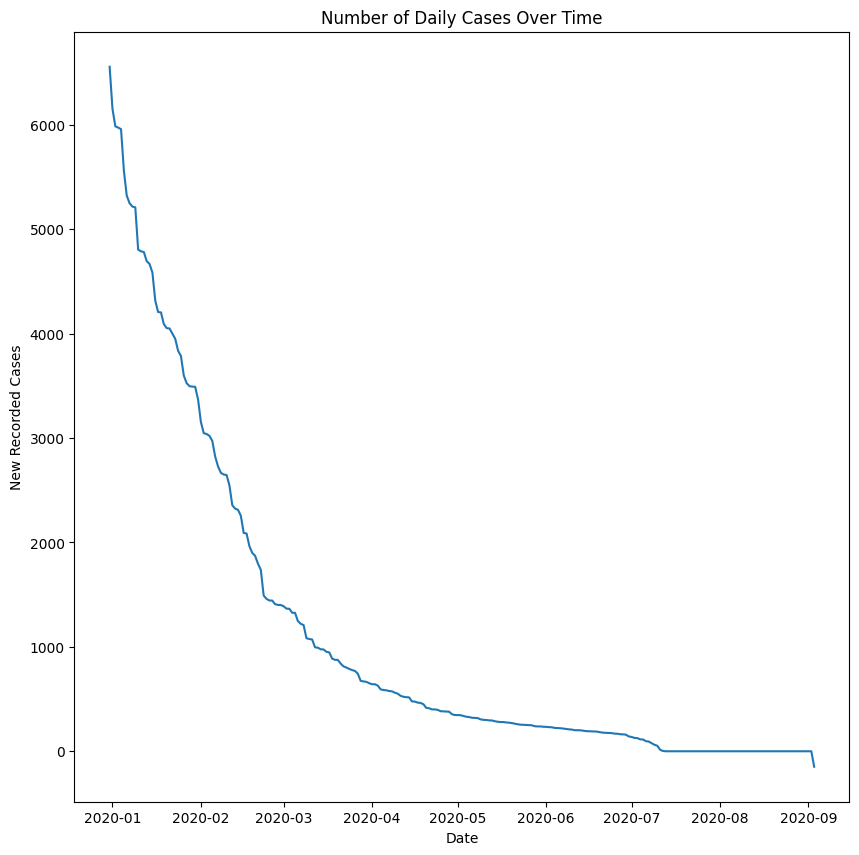

In [57]:
# Plot the date versus the new_cases
plt.figure(figsize=(10,10))
plt.plot(sorted_df_by_date['date'], df['new_cases'])
plt.xlabel('Date')
plt.ylabel('New Recorded Cases')
plt.title('Number of Daily Cases Over Time')
plt.show()